# 날씨 API로 배우는 데이터 수집 → 가공 → 시각화

**이 노트북 사용법**

- 셀을 **위에서부터 하나씩** 실행하세요. (셀 클릭 후 `Shift + Enter`)
- 셀마다 바로 결과가 나옵니다. 결과를 확인하고 다음 셀로 넘어가세요.
- 중간에 값을 바꿔보고, 그 셀부터 다시 실행해도 됩니다.
- 바꿔볼 만한 값은 `▼▼▼ ~ ▲▲▲` 로 표시해 두었습니다.

**전체 흐름**

`API 호출` → `표로 정리` → `기본 통계` → `그래프` → `업무 기준 적용` → `저장`

---
## 이 실습의 상황 설정

**상황**

당신은 건설 현장의 공무 담당자입니다. 매일 아침 기상청 홈페이지와 날씨 앱을
번갈아 보면서 "오늘 타설 가능한가?", "이번 주 중에 언제 하는 게 나은가?"를
판단하고, 그 내용을 정리해 현장에 공유하고 있습니다.

이 방식에는 세 가지 문제가 있습니다.

- **매번 사람이 봐야 합니다.** 담당자가 휴가면 아무도 안 봅니다.
- **판단 기준이 사람마다 다릅니다.** "비 좀 온다"가 누구에겐 중단, 누구에겐 진행입니다.
- **기록이 남지 않습니다.** 지난주에 왜 작업을 멈췄는지 나중에 설명하기 어렵습니다.

**그래서 만들 것**

날씨 데이터를 자동으로 받아와서, **우리가 정한 기준**에 따라
`작업가능 / 주의 / 중단` 으로 판정하고, 그 결과를 파일로 남기는 흐름을 만듭니다.

> 핵심은 "날씨를 보는 것"이 아니라
> **"숫자를 우리 업무의 판단으로 바꾸는 규칙을 코드로 고정하는 것"** 입니다.
> 한번 규칙을 정해두면 누가 실행해도 같은 결론이 나오고, 근거가 파일로 남습니다.

**답하려는 질문 4가지**

| 질문 | 어느 단계에서 답이 나오나 |
|---|---|
| 앞으로 2주간 날씨가 어떻게 흘러가나? | 4단계 (기온·강수 그래프) |
| 전체 336시간 중 작업 가능한 시간은 얼마나 되나? | 5단계 (상태별 분포) |
| **몇 시부터 몇 시까지 끊김 없이 작업할 수 있나?** | 5단계 (연속 구간 찾기) |
| 지난주 실제 날씨와 다음주 예보는 얼마나 다른가? | 6단계 (실측 vs 예보 비교) |

세 번째 질문이 특히 중요합니다. 타설은 중간에 끊을 수 없기 때문에
"총 작업가능 100시간"보다 "내일 9시부터 17시까지 8시간 연속 가능"이
현장에서 훨씬 쓸모 있는 정보입니다.

---
## 0단계. 준비물 확인

이 노트북은 아래 두 가지를 씁니다.

- **pandas** — 데이터를 엑셀 시트처럼 "표"로 다루게 해주는 도구
- **matplotlib** — 그래프를 그려주는 도구

설치가 안 되어 있다면 아래 셀의 `#` 을 지우고 한 번만 실행하세요.

In [ ]:
# 설치가 필요할 때만 맨 앞 # 을 지우고 실행하세요 (한 번만 하면 됩니다)
# %pip install pandas matplotlib

In [1]:
import json
import urllib.parse
import urllib.request

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# --- 그래프에 한글이 깨지지 않게 폰트를 지정합니다 ---
# 윈도우는 '맑은 고딕', 맥은 'AppleGothic' 이 기본으로 깔려 있습니다.
installed = {f.name for f in font_manager.fontManager.ttflist}
for candidate in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Gulim"]:
    if candidate in installed:
        plt.rcParams["font.family"] = candidate
        print(f"한글 폰트로 '{candidate}' 를 사용합니다.")
        break
else:
    print("한글 폰트를 못 찾았습니다. 그래프의 한글이 네모로 보일 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False   # 영하 기온의 '-' 기호가 깨지지 않게
plt.rcParams["figure.figsize"] = (11, 4)     # 그래프 기본 크기
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas 버전:", pd.__version__)
print("준비 완료!")

한글 폰트로 'Malgun Gothic' 를 사용합니다.
pandas 버전: 3.0.5
준비 완료!


---
## 1단계. 어느 지역을 볼지 정하기

**위도(latitude)** 와 **경도(longitude)** 는 지구 위의 한 지점을 가리키는 좌표입니다.
아래 값을 우리 사업장 좌표로 바꾸면, 이 노트북 전체가 그 지역 기준으로 다시 계산됩니다.

> 좌표 찾는 법: 구글 지도에서 원하는 위치를 우클릭하면 `37.5665, 126.9780` 형태로 나옵니다.
> (앞이 위도, 뒤가 경도)

In [2]:
# ▼▼▼ 여기만 바꾸면 다른 지역을 볼 수 있습니다 ▼▼▼
region = "서울"
latitude = 37.5665
longitude = 126.9780
# ▲▲▲ 여기까지 ▲▲▲

# 참고용 좌표 모음 (위 세 줄에 복사해서 쓰세요)
#   인천  37.4563, 126.7052
#   대전  36.3504, 127.3845
#   광주  35.1595, 126.8526
#   부산  35.1796, 129.0756
#   삼척  37.4500, 129.1650

print(f"{region} (위도 {latitude}, 경도 {longitude}) 기준으로 진행합니다.")

서울 (위도 37.5665, 경도 126.978) 기준으로 진행합니다.


---
## 어떤 데이터를 수집하나

**데이터 출처: Open-Meteo**

- 무료 공개 기상 API입니다. **회원가입·API 키·결제수단이 모두 필요 없습니다.**
- 주소(URL)에 조건만 적어 보내면 JSON 형식으로 데이터를 돌려줍니다.
- 기상청 API와 달리 신청·승인 절차가 없어서 실습에 적합합니다.

**수집 범위**

| 항목 | 값 | 의미 |
|---|---|---|
| 지역 | 1단계에서 정한 좌표 (기본: 서울 37.5665, 126.9780) | 위경도만 바꾸면 어느 현장이든 적용됩니다 |
| 과거 | 7일 (`past_days=7`) | 실제로 관측된 값 — "지난주는 이랬다" |
| 미래 | 7일 (`forecast_days=7`) | 예보값 — "다음주는 이럴 것이다" |
| 간격 | 1시간 | 총 **14일 × 24시간 = 약 336줄** |

과거와 미래를 함께 받는 이유는, 예보만 보면 그 예보가 믿을 만한지 알 수 없기 때문입니다.
지난주 실측과 나란히 놓고 봐야 "요즘 날씨 흐름에서 다음주가 어느 정도인지" 판단이 됩니다.

**수집 항목 6가지 — 왜 이것들을 골랐나**

| API 항목명 | 노트북 열 이름 | 단위 | 왜 필요한가 |
|---|---|---|---|
| `temperature_2m` | `temp` | °C | 혹서기(33도↑)·한중 양생(5도↓) 판단 |
| `apparent_temperature` | `feels_like` | °C | 실제 작업자가 느끼는 온도 (온열질환 관리) |
| `relative_humidity_2m` | `humidity` | % | 콘크리트 양생 속도, 도장 작업 가부 |
| `precipitation` | `precip` | mm | **실제로 내린/내릴 양** — 타설 중단의 직접 근거 |
| `precipitation_probability` | `precip_prob` | % | **비가 올 가능성** — 사전 일정 조정용 |
| `wind_speed_10m` | `wind` | km/h | 크레인·고소작업 중단 기준 (10m/s ≈ 36km/h) |

> **강수량과 강수확률은 다릅니다.** 확률 80%인데 강수량 0.1mm면 "잠깐 흩뿌리는 비"이고,
> 확률 40%인데 5mm면 "올 확률은 낮지만 오면 못 한다"입니다.
> 그래서 5단계에서 **둘 다 각각 기준을 걸어** 판정합니다.

일별 요약(`daily`)도 함께 요청하지만, 실습에서는 **과거/미래의 경계 날짜를 계산하는 용도**로만 씁니다.
분석은 전부 1시간 단위 데이터로 진행합니다.

**최종 산출물**

| 파일 | 용도 |
|---|---|
| `weather_hourly.csv` | 엑셀에서 바로 열어보는 336줄짜리 표 |
| `weather_processed.json` | 다음 실습(대시보드 HTML)이 읽어갈 데이터 |

---
## 2단계. API 호출하기

**API** 는 "정해진 주소로 요청을 보내면 데이터를 돌려주는 창구"입니다.
Open-Meteo는 회원가입도, 키도, 결제수단도 필요 없습니다. 주소만 알면 바로 받을 수 있습니다.

**파라미터**는 그 창구에 "이런 조건으로 주세요"라고 적어내는 신청서 항목이라고 보면 됩니다.

In [3]:
API_URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": latitude,
    "longitude": longitude,

    # hourly = 1시간 단위로 받을 항목들 (콤마로 여러 개 지정)
    "hourly": "temperature_2m,apparent_temperature,relative_humidity_2m,"
              "precipitation,precipitation_probability,wind_speed_10m",

    # daily = 하루 단위로 요약해서 받을 항목들
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max",

    "past_days": 7,      # 지난 7일 실제 관측값도 함께 (최대 92)
    "forecast_days": 7,  # 앞으로 7일 예보까지 (최대 16)
    "timezone": "auto",  # 그 좌표의 현지 시간 기준으로 맞춰줌
}

request_url = API_URL + "?" + urllib.parse.urlencode(params)

print("실제로 호출하는 주소입니다. 브라우저 주소창에 붙여넣어도 똑같은 결과가 보입니다.")
print()
print(request_url)

실제로 호출하는 주소입니다. 브라우저 주소창에 붙여넣어도 똑같은 결과가 보입니다.

https://api.open-meteo.com/v1/forecast?latitude=37.5665&longitude=126.978&hourly=temperature_2m%2Capparent_temperature%2Crelative_humidity_2m%2Cprecipitation%2Cprecipitation_probability%2Cwind_speed_10m&daily=temperature_2m_max%2Ctemperature_2m_min%2Cprecipitation_sum%2Cwind_speed_10m_max&past_days=7&forecast_days=7&timezone=auto


아래 셀을 실행하면 실제로 인터넷을 통해 데이터를 받아옵니다. 1~3초 정도 걸립니다.

In [4]:
with urllib.request.urlopen(request_url, timeout=30) as response:
    raw = json.loads(response.read().decode("utf-8"))

print("데이터를 받았습니다!")
print("- 기준 시간대:", raw["timezone"])
print("- 시간별 데이터:", len(raw["hourly"]["time"]), "시간분")
print("- 일별 데이터:", len(raw["daily"]["time"]), "일분")

데이터를 받았습니다!
- 기준 시간대: Asia/Seoul
- 시간별 데이터: 336 시간분
- 일별 데이터: 14 일분


---
## 3단계. 받은 데이터를 표(DataFrame)로 만들기

API가 준 데이터는 **JSON** 형식입니다. Open-Meteo는 조금 특이하게
**"항목별로 값이 쭉 나열된"** 구조로 줍니다.
`시간` 336개, `기온` 336개가 따로 있고 **같은 순번끼리 짝**이 되는 방식이죠.

In [5]:
print("시간별 안에 들어있는 항목:")
for key in raw["hourly"]:
    print("  -", key, "→", len(raw["hourly"][key]), "개")

print()
print("0번째 값들끼리 짝을 이룹니다:")
print("  시간:", raw["hourly"]["time"][0])
print("  기온:", raw["hourly"]["temperature_2m"][0], "도")

시간별 안에 들어있는 항목:
  - time → 336 개
  - temperature_2m → 336 개
  - apparent_temperature → 336 개
  - relative_humidity_2m → 336 개
  - precipitation → 336 개
  - precipitation_probability → 336 개
  - wind_speed_10m → 336 개

0번째 값들끼리 짝을 이룹니다:
  시간: 2026-08-24T00:00
  기온: 25.1 도


이 구조를 그대로 pandas에 넘기면, **엑셀 시트 같은 표**로 바뀝니다.
이렇게 만든 표를 **DataFrame(데이터프레임)** 이라고 부릅니다.

In [6]:
df = pd.DataFrame(raw["hourly"])

# 열 이름을 짧고 쓰기 편한 이름으로 바꿉니다
df = df.rename(columns={
    "time": "time",
    "temperature_2m": "temp",
    "apparent_temperature": "feels_like",
    "relative_humidity_2m": "humidity",
    "precipitation": "precip",
    "precipitation_probability": "precip_prob",
    "wind_speed_10m": "wind",
})

# 'time' 열을 글자가 아니라 진짜 '날짜/시간' 값으로 바꿔줍니다.
# 이렇게 해야 날짜 계산이나 그래프의 시간축이 제대로 동작합니다.
df["time"] = pd.to_datetime(df["time"])

print(f"표 크기: {df.shape[0]}줄 x {df.shape[1]}열")
df.head(10)      # 앞 10줄 보기 (숫자를 바꾸면 더 볼 수 있습니다)

표 크기: 336줄 x 7열


,time,temp,feels_like,humidity,precip,precip_prob,wind
0,2026-08-24 00:00:00,25.1,31.0,93,0.0,0,0.8
1,2026-08-24 01:00:00,24.5,29.9,94,0.0,1,2.5
2,2026-08-24 02:00:00,24.2,29.4,94,0.0,1,3.3
3,2026-08-24 03:00:00,23.9,29.1,95,0.0,2,2.7
4,2026-08-24 04:00:00,23.7,28.8,96,0.0,2,2.5
5,2026-08-24 05:00:00,23.6,28.8,97,0.0,3,2.9
6,2026-08-24 06:00:00,23.2,28.1,98,0.0,4,3.1
7,2026-08-24 07:00:00,23.4,28.7,98,0.0,8,1.8
8,2026-08-24 08:00:00,24.6,30.1,92,0.0,13,1.1
9,2026-08-24 09:00:00,26.3,32.0,84,0.0,16,0.7


### 열 이름이 영어라 헷갈린다면

| 열 이름 | 뜻 | 단위 |
|---|---|---|
| `time` | 시각 | |
| `temp` | 기온 | °C |
| `feels_like` | 체감온도 | °C |
| `humidity` | 습도 | % |
| `precip` | 강수량 | mm |
| `precip_prob` | 강수확률 | % |
| `wind` | 풍속 | km/h |

`df.head()` 는 앞부분만 보여줍니다. 표 전체의 성격을 한눈에 보려면 아래 두 가지를 씁니다.

- `df.info()` — 열 이름, 데이터 종류, 빠진 값이 있는지
- `df.describe()` — 개수·평균·최소·최대 등 **기본 통계를 한 번에**

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time         336 non-null    datetime64[us]
 1   temp         336 non-null    float64       
 2   feels_like   336 non-null    float64       
 3   humidity     336 non-null    int64         
 4   precip       336 non-null    float64       
 5   precip_prob  336 non-null    int64         
 6   wind         336 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 18.5 KB


### 기본 통계 한 번에 보기

`describe()` 한 줄이면 아래가 전부 나옵니다.

- `count` 개수 · `mean` 평균 · `std` 표준편차(값이 얼마나 흩어져 있는지)
- `min` 최소 · `25%` `50%`(중앙값) `75%` · `max` 최대

In [8]:
df.describe().round(1)

,time,temp,feels_like,humidity,precip,precip_prob,wind
count,336,336.0,336.0,336.0,336.0,336.0,336.0
mean,2026-08-30 23:30:00,24.5,28.2,81.1,0.4,28.6,5.4
min,2026-08-24 00:00:00,17.3,17.4,44.0,0.0,0.0,0.7
25%,2026-08-27 11:45:00,22.6,25.9,72.0,0.0,3.0,2.7
50%,2026-08-30 23:30:00,24.1,28.4,84.0,0.0,10.0,3.9
75%,2026-09-03 11:15:00,26.5,31.0,94.0,0.0,50.2,6.6
max,2026-09-06 23:00:00,32.3,38.6,99.0,33.7,100.0,19.8
std,NaN,3.0,4.3,14.1,2.3,34.2,4.1


> **읽는 요령**: `평균(mean)` 과 `중앙값(50%)` 이 많이 다르면, 한쪽에 값이 몰려 있다는 뜻입니다.
> 예를 들어 강수량은 대부분 0인데 특정 시간에만 확 쏟아지므로 평균이 중앙값보다 훨씬 큽니다.
> 그래서 **평균 하나만 보면 안 되고, 최대값과 분포를 같이 봐야 합니다.**

---
## 4단계. 그래프로 보기

숫자 표만 보면 흐름이 안 보입니다. 그림으로 그려봅시다.

먼저 **지난 7일(실측)** 과 **앞으로 7일(예보)** 을 구분할 표시를 만듭니다.

In [9]:
# past_days=7 로 요청했으므로, 일별 14일 중 앞 7일이 과거입니다.
last_past_day = pd.to_datetime(raw["daily"]["time"][params["past_days"] - 1])
forecast_start = last_past_day + pd.Timedelta(days=1)   # 이 시각부터는 예보

df["kind"] = df["time"].apply(
    lambda t: "실측" if t < forecast_start else "예보"
)

print(df["kind"].value_counts())
print()
print("예보 시작 시점:", forecast_start)

kind
실측    168
예보    168
Name: count, dtype: int64

예보 시작 시점: 2026-08-31 00:00:00


### 그래프 1 — 기온 흐름 (실측 vs 예보)

실선이 지난 7일 실제 관측값, 점선이 앞으로 7일 예보입니다.

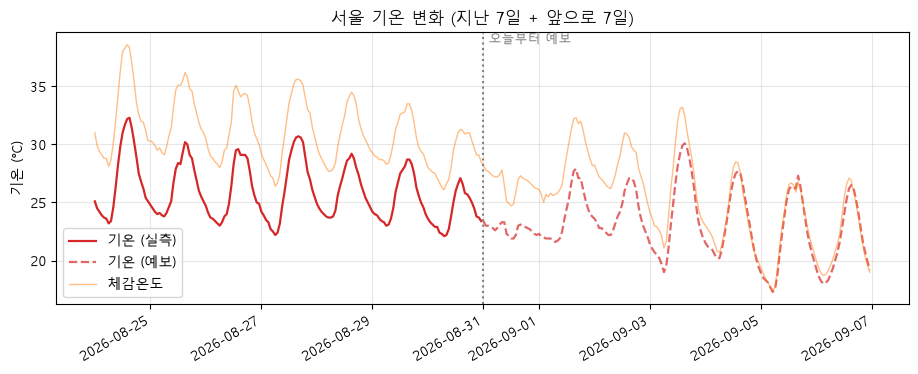

In [10]:
actual = df[df["kind"] == "실측"]
forecast = df[df["kind"] == "예보"]

fig, ax = plt.subplots()

ax.plot(actual["time"], actual["temp"],
        label="기온 (실측)", color="tab:red", linewidth=1.6)
ax.plot(forecast["time"], forecast["temp"],
        label="기온 (예보)", color="tab:red", linewidth=1.6,
        linestyle="--", alpha=0.7)
ax.plot(df["time"], df["feels_like"],
        label="체감온도", color="tab:orange", linewidth=1, alpha=0.5)

# 실측과 예보의 경계에 세로선을 긋습니다
ax.axvline(forecast_start, color="gray", linestyle=":", linewidth=1.5)
ax.text(forecast_start, ax.get_ylim()[1], " 오늘부터 예보",
        va="top", fontsize=9, color="gray")

ax.set_title(f"{region} 기온 변화 (지난 7일 + 앞으로 7일)")
ax.set_ylabel("기온 (°C)")
ax.legend(loc="lower left")
fig.autofmt_xdate()      # 날짜 라벨이 겹치지 않게 비스듬히
plt.show()

### 그래프 2 — 강수량과 강수확률 함께 보기

단위가 다른 두 값(mm 와 %)을 한 그래프에 그리려면 **축을 두 개** 씁니다.
막대는 실제로 내린 양(왼쪽 축), 선은 비가 올 가능성(오른쪽 축)입니다.

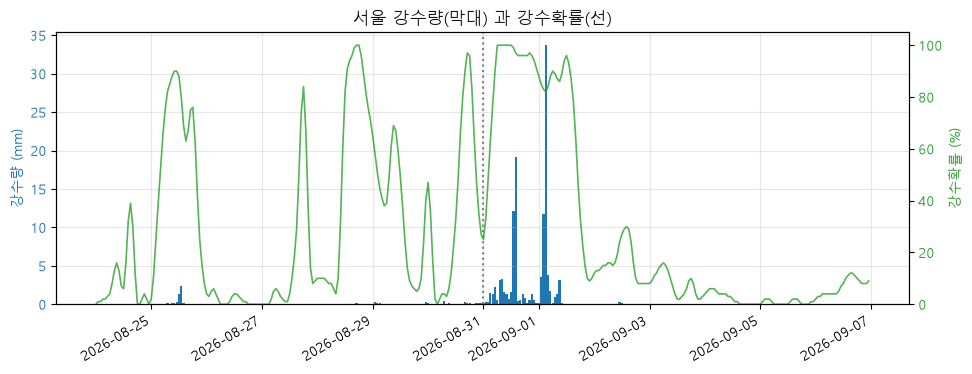

In [11]:
fig, ax1 = plt.subplots()

ax1.bar(df["time"], df["precip"], width=0.04,
        color="tab:blue", label="강수량 (mm)")
ax1.set_ylabel("강수량 (mm)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()        # 오른쪽에 축을 하나 더 만듭니다
ax2.plot(df["time"], df["precip_prob"], color="tab:green",
         linewidth=1.2, alpha=0.8, label="강수확률 (%)")
ax2.set_ylabel("강수확률 (%)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.set_ylim(0, 105)
ax2.grid(False)

ax1.axvline(forecast_start, color="gray", linestyle=":", linewidth=1.5)
ax1.set_title(f"{region} 강수량(막대) 과 강수확률(선)")
fig.autofmt_xdate()
plt.show()

---
## 5단계. 업무 기준을 적용해서 "판단"으로 바꾸기

여기가 이 실습의 핵심입니다.

`강수확률 82%` 라는 숫자 자체는 현장에서 바로 쓰기 어렵습니다.
**"그래서 타설을 할 수 있냐, 없냐"** 로 바꿔줘야 업무에 쓰이는 정보가 됩니다.

그 변환 규칙이 아래 **기준값**입니다.
정답이 있는 게 아니라, **우리 현장 사정에 맞게 우리가 정하는 값**입니다.

In [12]:
# ▼▼▼ 현장 사정에 맞게 자유롭게 바꿔보세요 ▼▼▼
STOP_PRECIP_PROB = 60    # 강수확률이 이 % 이상이면 중단
STOP_PRECIP = 1.0        # 강수량이 이 mm 이상이면 중단
STOP_WIND = 36           # 풍속이 이 km/h 이상이면 중단 (약 10 m/s)

WARN_PRECIP_PROB = 30    # 강수확률이 이 % 이상이면 주의
WARN_HOT = 33            # 기온이 이 °C 이상이면 주의 (혹서기)
WARN_COLD = 5            # 기온이 이 °C 이하면 주의 (한중 양생)
# ▲▲▲ 여기까지 ▲▲▲

STATUS_OK = "작업가능"
STATUS_WARN = "주의"
STATUS_STOP = "중단"


def judge(row):
    """한 시간치 데이터를 받아 '중단' / '주의' / '작업가능' 중 하나를 돌려줍니다."""
    if (row["precip_prob"] >= STOP_PRECIP_PROB
            or row["precip"] >= STOP_PRECIP
            or row["wind"] >= STOP_WIND):
        return STATUS_STOP
    if (row["precip_prob"] >= WARN_PRECIP_PROB
            or row["temp"] >= WARN_HOT
            or row["temp"] <= WARN_COLD):
        return STATUS_WARN
    return STATUS_OK


# apply = 표의 모든 줄에 위 함수를 한 번씩 적용해서, 결과를 새 열로 만듭니다
df["status"] = df.apply(judge, axis=1)

df[["time", "temp", "precip", "precip_prob", "wind", "status"]].head(12)

,time,temp,precip,precip_prob,wind,status
0,2026-08-24 00:00:00,25.1,0.0,0,0.8,작업가능
1,2026-08-24 01:00:00,24.5,0.0,1,2.5,작업가능
2,2026-08-24 02:00:00,24.2,0.0,1,3.3,작업가능
3,2026-08-24 03:00:00,23.9,0.0,2,2.7,작업가능
4,2026-08-24 04:00:00,23.7,0.0,2,2.5,작업가능
5,2026-08-24 05:00:00,23.6,0.0,3,2.9,작업가능
6,2026-08-24 06:00:00,23.2,0.0,4,3.1,작업가능
7,2026-08-24 07:00:00,23.4,0.0,8,1.8,작업가능
8,2026-08-24 08:00:00,24.6,0.0,13,1.1,작업가능
9,2026-08-24 09:00:00,26.3,0.0,16,0.7,작업가능


### 상태별로 몇 시간씩인지 세어보기

`value_counts()` 는 "각 값이 몇 번 나왔는지" 세어줍니다.

         시간  비율(%)
status            
작업가능    225   67.0
중단       80   23.8
주의       31    9.2



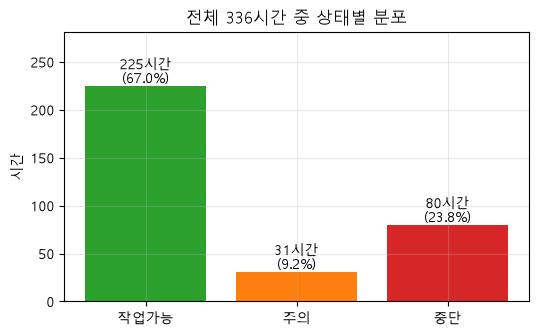

In [13]:
counts = df["status"].value_counts()
ratios = (counts / len(df) * 100).round(1)

summary = pd.DataFrame({"시간": counts, "비율(%)": ratios})
print(summary)
print()

STATUS_ORDER = [STATUS_OK, STATUS_WARN, STATUS_STOP]
STATUS_COLOR = {
    STATUS_OK: "tab:green",
    STATUS_WARN: "tab:orange",
    STATUS_STOP: "tab:red",
}

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(STATUS_ORDER,
       [counts.get(s, 0) for s in STATUS_ORDER],
       color=[STATUS_COLOR[s] for s in STATUS_ORDER])

for i, s in enumerate(STATUS_ORDER):
    n = counts.get(s, 0)
    ax.text(i, n, f"{n}시간\n({ratios.get(s, 0)}%)", ha="center", va="bottom")

ax.set_title(f"전체 {len(df)}시간 중 상태별 분포")
ax.set_ylabel("시간")
ax.set_ylim(0, max(counts) * 1.25)
plt.show()

### 날짜별 작업가능률

`groupby` 는 "같은 것끼리 묶어서 계산"하는 기능입니다.
여기서는 **날짜별로 묶어서** 각 날의 작업가능 시간을 세어봅니다.

In [14]:
df["date"] = df["time"].dt.date      # 시각에서 날짜 부분만 뽑기

# 날짜별 x 상태별로 몇 시간인지 표 만들기
by_date = df.groupby(["date", "status"]).size().unstack(fill_value=0)
for s in STATUS_ORDER:
    if s not in by_date.columns:
        by_date[s] = 0
by_date = by_date[STATUS_ORDER]

by_date["workable_rate"] = (
    by_date[STATUS_OK] / by_date.sum(axis=1) * 100
).round(1)

# 표로 보여줄 때만 열 이름을 한글로 바꿔줍니다 (원본 by_date 는 영어 그대로)
by_date.rename(columns={"workable_rate": "작업가능률(%)"})

status,작업가능,주의,중단,작업가능률(%)
date,,,,
2026-08-24,21,3,0,87.5
2026-08-25,6,3,15,25.0
2026-08-26,24,0,0,100.0
2026-08-27,19,2,3,79.2
2026-08-28,10,1,13,41.7
2026-08-29,9,11,4,37.5
2026-08-30,11,6,7,45.8
2026-08-31,1,2,21,4.2
2026-09-01,5,2,17,20.8


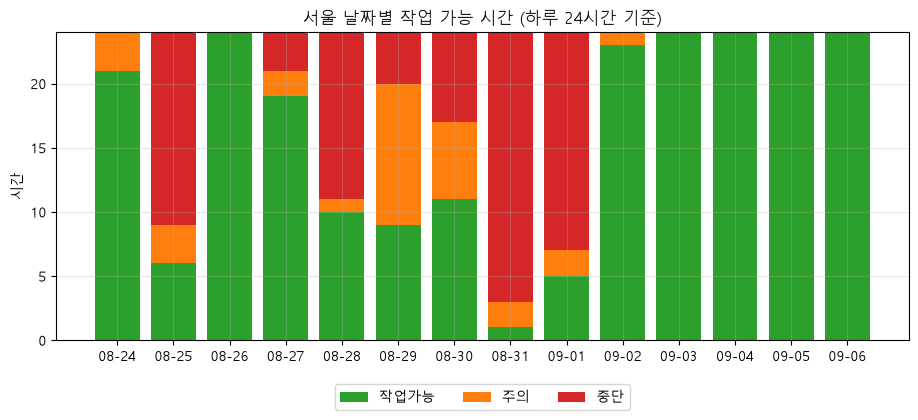

In [15]:
chart_data = by_date[STATUS_ORDER]
labels = [str(d)[5:] for d in chart_data.index]   # "08-22" 형태로 짧게

fig, ax = plt.subplots(figsize=(11, 4))
bottom = [0] * len(chart_data)
for s in STATUS_ORDER:
    ax.bar(labels, chart_data[s], bottom=bottom, label=s, color=STATUS_COLOR[s])
    bottom = [a + b for a, b in zip(bottom, chart_data[s])]

ax.set_title(f"{region} 날짜별 작업 가능 시간 (하루 24시간 기준)")
ax.set_ylabel("시간")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

### 연속으로 작업 가능한 구간 찾기

현장에서는 "작업가능 시간이 총 몇 시간"보다
**"몇 시부터 몇 시까지 쭉 이어서 가능한가"** 가 훨씬 중요합니다.
타설은 중간에 끊을 수 없으니까요.

In [16]:
# 상태가 바뀔 때마다 번호를 1씩 올려서, 같은 상태가 이어지는 덩어리에 같은 번호를 붙입니다
block_id = (df["status"] != df["status"].shift()).cumsum()

blocks = df.groupby(block_id).agg(
    status=("status", "first"),
    start=("time", "first"),
    end=("time", "last"),
    hours=("time", "size"),
)

workable = blocks[blocks["status"] == STATUS_OK].sort_values(
    "hours", ascending=False
)

print("연속 작업가능 구간 (긴 순서대로 상위 8개)")
print()
for _, row in workable.head(8).iterrows():
    print(f"  {row['start']:%m/%d %H시}  ~  {row['end']:%m/%d %H시}"
          f"   ({row['hours']}시간 연속)")

if len(workable) > 0:
    longest = workable.iloc[0]
    print()
    print(f"→ 가장 긴 구간은 {longest['hours']}시간입니다.")
else:
    print("  작업가능 구간이 없습니다. 기준값을 조정해보세요.")

연속 작업가능 구간 (긴 순서대로 상위 8개)

  09/02 15시  ~  09/06 23시   (105시간 연속)
  08/25 21시  ~  08/27 15시   (43시간 연속)
  09/01 19시  ~  09/02 13시   (19시간 연속)
  08/24 00시  ~  08/24 13시   (14시간 연속)
  08/27 21시  ~  08/28 09시   (13시간 연속)
  08/30 02시  ~  08/30 11시   (10시간 연속)
  08/24 17시  ~  08/25 02시   (10시간 연속)
  08/29 14시  ~  08/29 22시   (9시간 연속)

→ 가장 긴 구간은 105시간입니다.


---
## 6단계. 지난 7일(실측) vs 앞으로 7일(예보) 비교

`groupby` 로 "실측"과 "예보"를 묶어서 한 번에 비교합니다.

In [17]:
compare = df.groupby("kind").agg(
    hours=("temp", "size"),
    temp_mean=("temp", "mean"),
    temp_max=("temp", "max"),
    precip_total=("precip", "sum"),
    humidity_mean=("humidity", "mean"),
    wind_max=("wind", "max"),
).round(1)

compare["workable_hours"] = df[df["status"] == STATUS_OK].groupby("kind").size()
compare["workable_rate"] = (
    compare["workable_hours"] / compare["hours"] * 100
).round(1)

# 실측이 위로 오도록 순서 정리
compare = compare.reindex([k for k in ["실측", "예보"] if k in compare.index])

# 표로 보여줄 때만 열 이름을 한글로 바꿔줍니다
compare.rename(columns={
    "hours": "시간수",
    "temp_mean": "평균기온",
    "temp_max": "최고기온",
    "precip_total": "총강수량",
    "humidity_mean": "평균습도",
    "wind_max": "최대풍속",
    "workable_hours": "작업가능시간",
    "workable_rate": "작업가능률(%)",
})

,시간수,평균기온,최고기온,총강수량,평균습도,최대풍속,작업가능시간,작업가능률(%)
kind,,,,,,,,
실측,168,25.9,32.3,7.3,85.5,7.0,100,59.5
예보,168,23.1,30.1,115.6,76.7,19.8,125,74.4


---
## 7단계. 결과를 파일로 저장하기

다음 단계(대시보드 만들기)에서 쓸 수 있게 두 가지 형태로 남깁니다.

- **CSV** — 엑셀에서 바로 열어볼 수 있는 표
- **JSON** — 대시보드 HTML이 읽어갈 데이터

In [18]:
# 1) 엑셀에서 열어볼 수 있는 CSV
#    encoding="utf-8-sig" 로 저장해야 엑셀에서 한글이 깨지지 않습니다
export_cols = ["time", "temp", "feels_like", "humidity",
               "precip", "precip_prob", "wind", "kind", "status"]
export = df[export_cols]
export.to_csv("weather_hourly.csv", index=False, encoding="utf-8-sig")
print("weather_hourly.csv 저장 완료 —", len(export), "줄")

# 2) 대시보드가 읽어갈 JSON
result = {
    "region": region,
    "latitude": latitude,
    "longitude": longitude,
    "timezone": raw["timezone"],
    "generated_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "thresholds": {
        "stop_precip_prob": STOP_PRECIP_PROB,
        "stop_precip": STOP_PRECIP,
        "stop_wind": STOP_WIND,
        "warn_precip_prob": WARN_PRECIP_PROB,
        "warn_hot": WARN_HOT,
        "warn_cold": WARN_COLD,
    },
    "summary": {
        "temp_min": float(df["temp"].min()),
        "temp_mean": round(float(df["temp"].mean()), 1),
        "temp_max": float(df["temp"].max()),
        "precip_total": round(float(df["precip"].sum()), 1),
        "wind_max": float(df["wind"].max()),
        "status_counts": counts.to_dict(),
    },
    "daily": by_date.reset_index().assign(
        date=lambda x: x["date"].astype(str)
    ).to_dict(orient="records"),
    "hourly": export.assign(
        time=lambda x: x["time"].dt.strftime("%Y-%m-%dT%H:%M")
    ).to_dict(orient="records"),
}

with open("weather_processed.json", "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print("weather_processed.json 저장 완료")
print()
print("두 파일 모두 이 노트북과 같은 폴더에 있습니다.")

weather_hourly.csv 저장 완료 — 336 줄
weather_processed.json 저장 완료

두 파일 모두 이 노트북과 같은 폴더에 있습니다.


---
## 직접 해보기

아래를 하나씩 바꿔보고, **해당 셀부터 다시 실행**해서 결과가 어떻게 달라지는지 확인해보세요.

1. **다른 지역으로** — 1단계의 `latitude` / `longitude` 를 바꾸고 처음부터 다시 실행
2. **기준을 엄격하게 / 느슨하게** — 5단계의 `STOP_PRECIP_PROB` 을 `40` 또는 `80` 으로
3. **기간 늘리기** — 2단계의 `past_days` 를 `30` 으로 바꾸면 한 달치 통계가 나옵니다
4. **항목 추가하기** — 2단계 `hourly` 뒤에 항목을 붙이면 함께 옵니다
   - `,cloud_cover` — 구름량
   - `,surface_pressure` — 기압
   - `,weather_code` — 날씨코드(맑음/비/눈)

   추가한 뒤에는 3단계의 `rename` 에도 짧은 이름을 한 줄 넣어주세요.

### 표를 더 다뤄보고 싶다면

```python
df[df["status"] == "중단"]                          # 중단인 시간만 골라 보기
df[df["temp"] > 30]                                  # 30도 넘는 시간만
df.sort_values("precip", ascending=False).head(10)   # 비 많이 온 순서 10개
df.groupby("date")["temp"].max()                     # 날짜별 최고기온
```

---

## 다음 단계

여기서 만든 `weather_processed.json` 을 가지고
**그래프와 통계 카드가 있는 대시보드 HTML 페이지**를 만듭니다.